# Fake News Detection Using Support Vector Machine

Student ID: CIT-24-01-0072  
Machine Learning Model: Support Vector Machine (SVM)  
Task: Fake and Real News Classification


In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path
import sys

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root  :", PROJECT_ROOT)
print("Data folder   :", DATA_DIR)
print("Models folder :", MODELS_DIR)
print("Reports folder:", REPORTS_DIR)

Project root  : c:\Users\Imesh\Documents\NLP_Group_39
Data folder   : c:\Users\Imesh\Documents\NLP_Group_39\data
Models folder : c:\Users\Imesh\Documents\NLP_Group_39\models
Reports folder: c:\Users\Imesh\Documents\NLP_Group_39\reports


In [3]:
from data_loader import load_news_data
from preprocessing import clean_text

print("Data loading and preprocessing functions imported successfully.")

Data loading and preprocessing functions imported successfully.


In [4]:
dataset = load_news_data()

print("Dataset loaded successfully.")
print("Dataset shape:", dataset.shape)

dataset.head()

Dataset loaded successfully.
Dataset shape: (39103, 6)


,title,text,subject,date,label,content
0,First Somali Refugee Elected In American Hist...,"On November 8, 2016, Ilhan Omar made history a...",News,"December 8, 2016",0,First Somali Refugee Elected In American Histo...
1,MY LAST VIDEO EVER?…Paul Joseph Watson Explain...,This video should rock every advocate of free...,politics,"Mar 24, 2017",0,MY LAST VIDEO EVER?…Paul Joseph Watson Explain...
2,GOP Third-Party Candidate Live-Tweets Trump’s...,It s only been a few weeks since CIA veteran E...,News,"August 15, 2016",0,GOP Third-Party Candidate Live-Tweets Trump’s ...
3,BREAKING NEWS: Woman Who Narrated BRUTAL TORTU...,When four Chicago thugs videotaped the brutal ...,politics,"Dec 9, 2017",0,BREAKING NEWS: Woman Who Narrated BRUTAL TORTU...
4,Iran warns U.S. against imposing further sanct...,BEIRUT/DUBAI (Reuters) - Iran warned the Unite...,worldnews,"October 8, 2017",1,Iran warns U.S. against imposing further sanct...


In [5]:
print("Dataset columns:")
print(dataset.columns.tolist())

print("\nDataset information:")
dataset.info()

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nClass distribution:")
print(dataset["label"].value_counts().sort_index())

print("\nLabel mapping:")
print("0 = Fake News")
print("1 = Real News")

Dataset columns:
['title', 'text', 'subject', 'date', 'label', 'content']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 39103 entries, 0 to 39102
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    39103 non-null  str  
 1   text     39103 non-null  str  
 2   subject  39103 non-null  str  
 3   date     39103 non-null  str  
 4   label    39103 non-null  int64
 5   content  39103 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.8 MB

Missing values:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64

Class distribution:
label
0    17907
1    21196
Name: count, dtype: int64

Label mapping:
0 = Fake News
1 = Real News


## Data Preprocessing

The news text is normalized by converting it to lowercase and removing URLs, email addresses, HTML tags, numbers, punctuation marks, special characters, and unnecessary spaces.

In [6]:
svm_dataset = dataset.copy()

print("Starting SVM text preprocessing...")

svm_dataset["clean_content"] = (
    svm_dataset["content"]
    .astype(str)
    .apply(clean_text)
)

# Remove empty articles after preprocessing
svm_dataset = svm_dataset[
    svm_dataset["clean_content"].str.strip() != ""
].copy()

svm_dataset = svm_dataset.reset_index(drop=True)

print("Text preprocessing completed.")

print("Original dataset shape:", dataset.shape)
print("Cleaned dataset shape :", svm_dataset.shape)

print("\nMissing values after preprocessing:")
print(
    svm_dataset[
        ["content", "clean_content", "label"]
    ].isnull().sum()
)

Starting SVM text preprocessing...
Text preprocessing completed.
Original dataset shape: (39103, 6)
Cleaned dataset shape : (39098, 7)

Missing values after preprocessing:
content          0
clean_content    0
label            0
dtype: int64


In [7]:
sample_original = svm_dataset.loc[0, "content"]
sample_cleaned = svm_dataset.loc[0, "clean_content"]

print("Original text:")
print(sample_original[:500])

print("\nCleaned text:")
print(sample_cleaned[:500])

Original text:
First Somali Refugee Elected In American History Subjected To Islamophobic Attack On November 8, 2016, Ilhan Omar made history as being the first Somali-American to be elected to any position in America. Hailing from the progressive state of Minnesota, Omar will serve in the state House of Representatives from the 60B district. Running on the Democratic-Farmer-Labor Party, Omar supports progressive causes championed by Hillary Clinton and Bernie Sanders, Omar won with 81 percent of the vote.The 

Cleaned text:
first somali refugee elected in american history subjected to islamophobic attack on november ilhan omar made history as being the first somali american to be elected to any position in america hailing from the progressive state of minnesota omar will serve in the state house of representatives from the b district running on the democratic farmer labor party omar supports progressive causes championed by hillary clinton and bernie sanders omar won with percent of t

## Exploratory Data Analysis

This section examines the class distribution, article length patterns, and frequently occurring words in fake and real news articles.

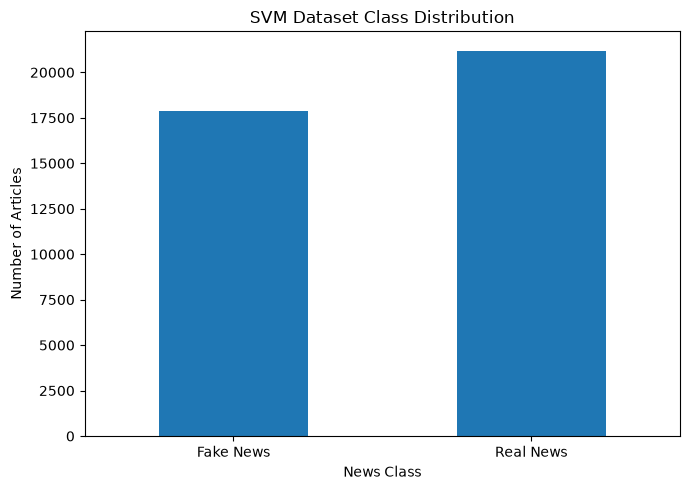

Class distribution:
label
0    17902
1    21196
Name: count, dtype: int64

Chart saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_class_distribution.png


In [8]:
svm_class_distribution = (
    svm_dataset["label"]
    .value_counts()
    .sort_index()
)

class_names = svm_class_distribution.rename(
    index={
        0: "Fake News",
        1: "Real News"
    }
)

class_names.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("SVM Dataset Class Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()

svm_class_chart_path = (
    REPORTS_DIR
    / "svm_class_distribution.png"
)

plt.savefig(
    svm_class_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Class distribution:")
print(svm_class_distribution)

print("\nChart saved to:")
print(svm_class_chart_path)

In [9]:
svm_dataset["word_count"] = (
    svm_dataset["clean_content"]
    .str.split()
    .str.len()
)

article_length_summary = (
    svm_dataset
    .groupby("label")["word_count"]
    .describe()
)

print("Article length summary:")
display(article_length_summary)

Article length summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17902.0,435.195676,361.337814,3.0,284.0,392.0,521.0,8295.0
1,21196.0,397.829968,276.649016,4.0,158.0,371.0,536.0,5254.0


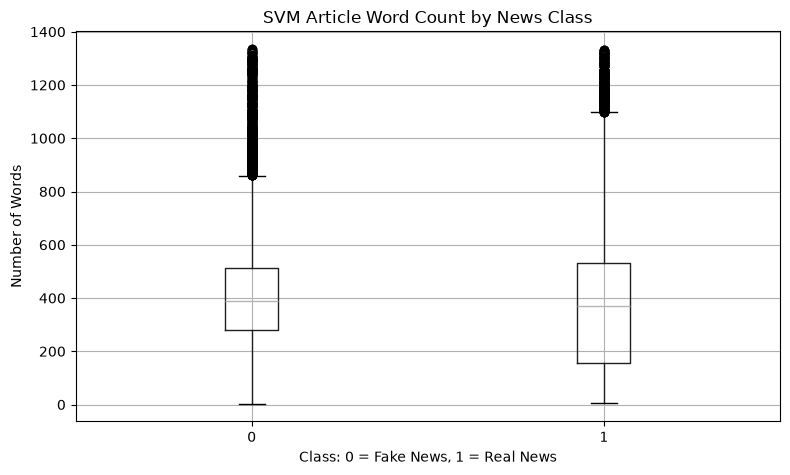

Chart saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_article_length_distribution.png


In [10]:
maximum_display_length = (
    svm_dataset["word_count"].quantile(0.99)
)

length_plot_data = svm_dataset[
    svm_dataset["word_count"] <= maximum_display_length
].copy()

length_plot_data.boxplot(
    column="word_count",
    by="label",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("SVM Article Word Count by News Class")
plt.xlabel("Class: 0 = Fake News, 1 = Real News")
plt.ylabel("Number of Words")
plt.tight_layout()

svm_length_chart_path = (
    REPORTS_DIR
    / "svm_article_length_distribution.png"
)

plt.savefig(
    svm_length_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:")
print(svm_length_chart_path)

In [11]:
def get_top_words(text_data, number_of_words=15):
    """
    Find the most frequent words in a collection
    of news articles.
    """

    sample_size = min(
        5000,
        len(text_data)
    )

    sampled_text = text_data.sample(
        n=sample_size,
        random_state=42
    )

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000
    )

    word_matrix = vectorizer.fit_transform(
        sampled_text.astype(str)
    )

    frequencies = word_matrix.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    frequency_table = pd.DataFrame(
        {
            "Word": words,
            "Frequency": frequencies
        }
    )

    return (
        frequency_table
        .sort_values(
            "Frequency",
            ascending=False
        )
        .head(number_of_words)
        .reset_index(drop=True)
    )


print("Top-word function created successfully.")

Top-word function created successfully.


In [12]:
fake_top_words = get_top_words(
    svm_dataset.loc[
        svm_dataset["label"] == 0,
        "clean_content"
    ]
)

print("Most Frequent Words in Fake News:")
display(fake_top_words)

Most Frequent Words in Fake News:


,Word,Frequency
0,trump,20743
1,said,7004
2,people,5891
3,president,5887
4,just,5004
5,obama,4462
6,donald,4412
7,clinton,4215
8,like,4126
9,video,3569


In [13]:
real_top_words = get_top_words(
    svm_dataset.loc[
        svm_dataset["label"] == 1,
        "clean_content"
    ]
)

print("Most Frequent Words in Real News:")
display(real_top_words)

Most Frequent Words in Real News:


,Word,Frequency
0,said,23014
1,trump,13707
2,reuters,6715
3,president,6675
4,state,5087
5,government,4412
6,house,4350
7,new,4183
8,states,3982
9,republican,3949


In [14]:
X = svm_dataset["clean_content"].astype(str)
y = svm_dataset["label"].astype(int)

print("Number of news articles:", len(X))
print("Number of labels       :", len(y))

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Number of news articles: 39098
Number of labels       : 39098

Target distribution:
label
0    17902
1    21196
Name: count, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

print("\nTraining records:", len(X_train))
print("Testing records :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Train-test split completed successfully.

Training records: 31278
Testing records : 7820

Training class distribution:
label
0    14321
1    16957
Name: count, dtype: int64

Testing class distribution:
label
0    3581
1    4239
Name: count, dtype: int64


## Feature Engineering Using TF-IDF

TF-IDF converts cleaned news articles into numerical feature vectors. Unigrams and bigrams are used to represent individual words and short word sequences for the SVM classifier.

In [16]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created successfully.")

TF-IDF vectorizer created successfully.


In [17]:
print("TF-IDF feature extraction started...")

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test
)

print("TF-IDF feature extraction completed.")

print("\nTraining feature shape:", X_train_tfidf.shape)
print("Testing feature shape :", X_test_tfidf.shape)

print(
    "Vocabulary size:",
    len(tfidf_vectorizer.vocabulary_)
)

TF-IDF feature extraction started...
TF-IDF feature extraction completed.

Training feature shape: (31278, 50000)
Testing feature shape : (7820, 50000)
Vocabulary size: 50000


In [18]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("First 20 TF-IDF features:")
print(feature_names[:20])

print("\nLast 20 TF-IDF features:")
print(feature_names[-20:])

First 20 TF-IDF features:
['aa' 'aapl' 'aaron' 'aaron bernstein' 'aarp' 'ab' 'aba' 'ababa' 'aback'
 'abadi' 'abadi office' 'abadi said' 'abandon' 'abandon nuclear'
 'abandoned' 'abandoning' 'abandonment' 'abbas' 'abbas said' 'abbasi']

Last 20 TF-IDF features:
['zippers' 'zone' 'zone budget' 'zone finance' 'zone listen' 'zone syria'
 'zones' 'zones syria' 'zoning' 'zoo' 'zor' 'zor city' 'zor province'
 'zucker' 'zuckerberg' 'zuckerberg said' 'zuma' 'zuma said' 'zurich'
 'zurich reuters']


## Support Vector Machine Model Development

Linear Support Vector Machine is selected because it performs effectively with high-dimensional sparse TF-IDF text features. Probability calibration is added to generate confidence scores and ROC-AUC values.

In [19]:
base_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

print("Base Linear SVM model created successfully.")

Base Linear SVM model created successfully.


In [20]:
svm_model = CalibratedClassifierCV(
    estimator=base_svm_model,
    method="sigmoid",
    cv=3,
    n_jobs=-1
)

print("Calibrated SVM model created successfully.")

Calibrated SVM model created successfully.


In [21]:
svm_model = CalibratedClassifierCV(
    base_svm_model,
    method="sigmoid",
    cv=3
)

In [22]:
print("SVM model training started...")

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("SVM model training completed successfully.")

SVM model training started...
SVM model training completed successfully.


In [23]:
y_pred = svm_model.predict(
    X_test_tfidf
)

y_probability = svm_model.predict_proba(
    X_test_tfidf
)[:, 1]

print("SVM predictions generated successfully.")

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].to_numpy())

print("\nFirst 10 Real News probabilities:")
print(y_probability[:10])

SVM predictions generated successfully.

First 10 predicted labels:
[1 0 1 1 0 1 1 0 1 1]

First 10 actual labels:
[1 0 1 1 0 1 1 0 1 1]

First 10 Real News probabilities:
[9.99831612e-01 2.05964981e-04 9.99997439e-01 9.99995568e-01
 9.14436306e-08 9.99791938e-01 9.99987723e-01 2.55030296e-07
 9.69250941e-01 9.95968049e-01]


In [24]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred
)

svm_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

svm_roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("SVM Evaluation Results")
print("=" * 45)

print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-Score  : {svm_f1:.4f}")
print(f"ROC-AUC   : {svm_roc_auc:.4f}")

SVM Evaluation Results
Accuracy  : 0.9965
Precision : 0.9972
Recall    : 0.9965
F1-Score  : 0.9968
ROC-AUC   : 0.9998


In [25]:
svm_classification_report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Fake News",
        "Real News"
    ],
    zero_division=0
)

print("SVM Classification Report")
print("=" * 55)
print(svm_classification_report)

SVM Classification Report
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      3581
   Real News       1.00      1.00      1.00      4239

    accuracy                           1.00      7820
   macro avg       1.00      1.00      1.00      7820
weighted avg       1.00      1.00      1.00      7820



In [26]:
print("Exact SVM Evaluation Results")
print("=" * 45)

print(f"Accuracy  : {svm_accuracy:.6f}")
print(f"Precision : {svm_precision:.6f}")
print(f"Recall    : {svm_recall:.6f}")
print(f"F1-Score  : {svm_f1:.6f}")
print(f"ROC-AUC   : {svm_roc_auc:.6f}")

Exact SVM Evaluation Results
Accuracy  : 0.996547
Precision : 0.997167
Recall    : 0.996461
F1-Score  : 0.996814
ROC-AUC   : 0.999757


In [27]:
train_text_set = set(X_train.astype(str))
test_text_set = set(X_test.astype(str))

overlapping_articles = train_text_set.intersection(
    test_text_set
)

print("Exact duplicate articles shared between train and test:")
print(len(overlapping_articles))

Exact duplicate articles shared between train and test:
74


## SVM Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified fake and real news articles.

In [28]:
svm_confusion_values = confusion_matrix(
    y_test,
    y_pred
)

print("SVM Confusion Matrix:")
print(svm_confusion_values)

true_fake = svm_confusion_values[0, 0]
false_real = svm_confusion_values[0, 1]
false_fake = svm_confusion_values[1, 0]
true_real = svm_confusion_values[1, 1]

print("\nConfusion Matrix Explanation")
print("=" * 45)

print(
    "Fake news correctly predicted as Fake :",
    true_fake
)

print(
    "Fake news incorrectly predicted as Real:",
    false_real
)

print(
    "Real news incorrectly predicted as Fake:",
    false_fake
)

print(
    "Real news correctly predicted as Real  :",
    true_real
)

SVM Confusion Matrix:
[[3569   12]
 [  15 4224]]

Confusion Matrix Explanation
Fake news correctly predicted as Fake : 3569
Fake news incorrectly predicted as Real: 12
Real news incorrectly predicted as Fake: 15
Real news correctly predicted as Real  : 4224


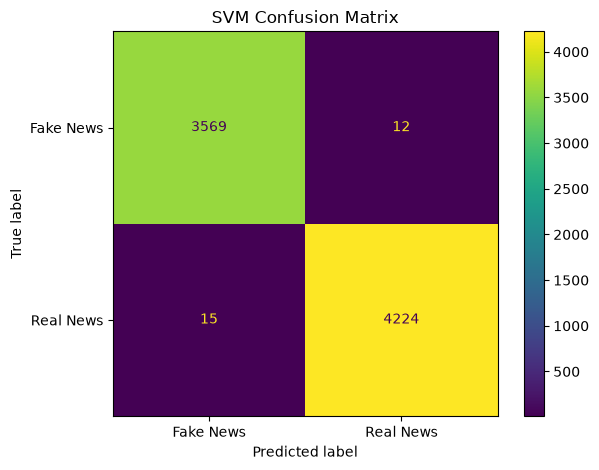

Confusion matrix saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_confusion_matrix.png


In [29]:
svm_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=svm_confusion_values,
    display_labels=[
        "Fake News",
        "Real News"
    ]
)

svm_matrix_display.plot(
    values_format="d"
)

plt.title("SVM Confusion Matrix")
plt.tight_layout()

svm_confusion_matrix_path = (
    REPORTS_DIR
    / "svm_confusion_matrix.png"
)

plt.savefig(
    svm_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(svm_confusion_matrix_path)

## SVM ROC Curve

The ROC curve evaluates the SVM model across different classification thresholds. A ROC-AUC score closer to 1 indicates stronger classification performance.

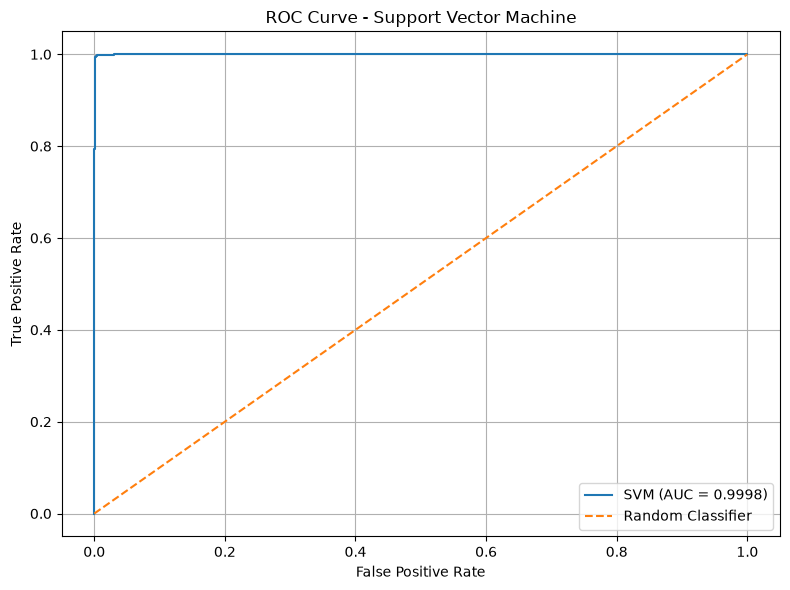

ROC curve saved to:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_roc_curve.png


In [30]:
svm_false_positive_rate, svm_true_positive_rate, thresholds = (
    roc_curve(
        y_test,
        y_probability
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_false_positive_rate,
    svm_true_positive_rate,
    label=f"SVM (AUC = {svm_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Support Vector Machine")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()

svm_roc_curve_path = (
    REPORTS_DIR
    / "svm_roc_curve.png"
)

plt.savefig(
    svm_roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved to:")
print(svm_roc_curve_path)

In [31]:
svm_metrics_dataframe = pd.DataFrame(
    {
        "Model": ["Support Vector Machine"],
        "Accuracy": [svm_accuracy],
        "Precision": [svm_precision],
        "Recall": [svm_recall],
        "F1-Score": [svm_f1],
        "ROC-AUC": [svm_roc_auc]
    }
)

svm_metrics_path = (
    REPORTS_DIR
    / "svm_metrics.csv"
)

svm_metrics_dataframe.to_csv(
    svm_metrics_path,
    index=False
)

print("SVM metrics saved successfully.")

display(svm_metrics_dataframe)

print("\nMetrics file:")
print(svm_metrics_path)

SVM metrics saved successfully.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.996547,0.997167,0.996461,0.996814,0.999757



Metrics file:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_metrics.csv


In [32]:
svm_prediction_results = pd.DataFrame(
    {
        "News_Text": X_test.to_numpy(),
        "Actual_Label": y_test.to_numpy(),
        "Predicted_Label": y_pred,
        "Real_News_Probability": y_probability,
        "Fake_News_Probability": (
            1 - y_probability
        )
    }
)

svm_predictions_path = (
    REPORTS_DIR
    / "svm_test_predictions.csv"
)

svm_prediction_results.to_csv(
    svm_predictions_path,
    index=False
)

print("SVM test predictions saved successfully.")
print(
    "Number of saved predictions:",
    len(svm_prediction_results)
)

display(svm_prediction_results.head())

print("\nPredictions file:")
print(svm_predictions_path)

SVM test predictions saved successfully.
Number of saved predictions: 7820


,News_Text,Actual_Label,Predicted_Label,Real_News_Probability,Fake_News_Probability
0,factbox conservative liberal progressive merke...,1,1,9.998316e-01,0.000168
1,watch students walk out during mike pence s co...,0,0,2.059650e-04,0.999794
2,trumps says expects republican nominee romney ...,1,1,9.999974e-01,0.000003
3,u s backed by china proposes tough n korea san...,1,1,9.999956e-01,0.000004
4,nra board member ted nugent just encouraged hi...,0,0,9.144363e-08,1.000000



Predictions file:
c:\Users\Imesh\Documents\NLP_Group_39\reports\svm_test_predictions.csv


In [33]:
svm_model_path = (
    MODELS_DIR
    / "svm_model.joblib"
)

svm_vectorizer_path = (
    MODELS_DIR
    / "svm_tfidf_vectorizer.joblib"
)

joblib.dump(
    svm_model,
    svm_model_path
)

joblib.dump(
    tfidf_vectorizer,
    svm_vectorizer_path
)

print("SVM model and TF-IDF vectorizer saved successfully.")

print("\nModel path:")
print(svm_model_path)

print("\nVectorizer path:")
print(svm_vectorizer_path)

SVM model and TF-IDF vectorizer saved successfully.

Model path:
c:\Users\Imesh\Documents\NLP_Group_39\models\svm_model.joblib

Vectorizer path:
c:\Users\Imesh\Documents\NLP_Group_39\models\svm_tfidf_vectorizer.joblib
